## Clase: Análisis Multivariable con Clustering
**Duración:** 1 hora 40 minutos  
**Módulo:** Identificación de variables clave de rentabilidad y segmentación de clientes  
**Objetivo de la sesión:** Utilizar técnicas de clustering para identificar segmentos significativos en los datos financieros y de clientes, y analizar su relación con KPIs de rentabilidad.

### Caso base: Gabu, startup de supervisión de niños mientras juegan online
**Situación:** La empresa desea entender mejor a sus clientes y categorizar de acuerdo a datos demograficos para personalizar campañas de adquisición de clientes y aumentar el uso de la plataforma.
**Datos:** Datos anonimizados de usuarios, incluyendo edad del niño, sexo, nivel educativo del padre/madre, frecuencia de uso, ticket promedio, etc.

- customer_id: ID del cliente, padre o tutor del niño.
- kid_id: ID del niño.
- kids_age: Edad del niño.
- kids_sex: Sexo del niño. 0 niño, 1 niña.
- family_income: Ingreso anual de la familia
- subscription_type: Tipo de suscripción (Básica, Premium, Familiar).
- monthly_fee: Tarifa mensual pagada por el usuario en USD. En el plan familiar se cobra $35 USD por toda la familia.
- avg_session_time: Promedio de tiempo de sesión en minutos.
- customer_support_tickets: Tickets de soporte abiertos por el cliente.
- issue_resolution_time: Tiempo promedio de resolución de tickets en horas.
- tenure: Meses que han pasado desde que el niño se unió a Gabu.
- signup_channel: Canal de adquisición del padre o tutor.
- total_sessions: Número total de sesiones en la plataforma.
- churn: 1 si el cliente canceló su suscripción, 0 si sigue activo.

**¿Que variables deberíamos de usar?**

---

### Parte 1: Introducción a Análisis Multivariable y Clustering (20 min)

- **Concepto de análisis multivariable:** exploración de relaciones entre múltiples variables.
- **Concepto de clustering:** técnica de aprendizaje no supervisado para segmentación.
- **Aplicaciones en negocios:** segmentación de clientes, detección de patrones de consumo, personalización de estrategias.

**Ejemplo breve:** visualización 2D de datos ficticios y agrupamiento por colores (usando Seaborn y KMeans).

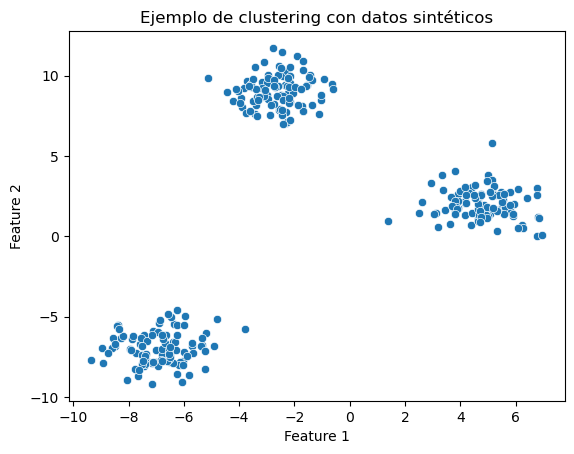

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Creamos un dataset de ejemplo
X_blob, y_blob = make_blobs(n_samples=300, centers=3, random_state=42)
X_prueba = pd.DataFrame(X_blob)

# Visualizamos
sns.scatterplot(x=X_prueba[0], y=X_prueba[1])
plt.title("Ejemplo de clustering con datos sintéticos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


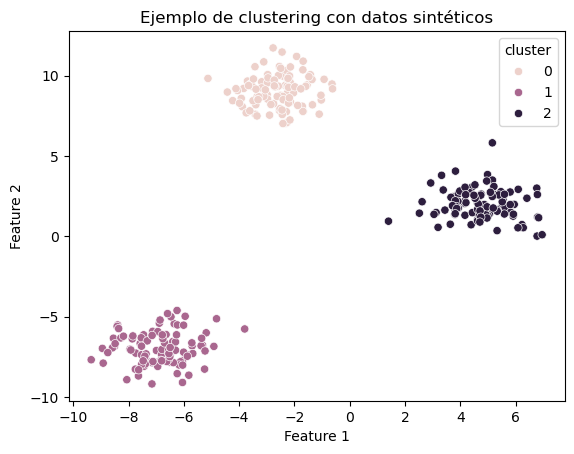

In [24]:
from sklearn.cluster import KMeans

model = KMeans(n_clusters=3, random_state=42)
X_prueba["cluster"] = model.fit_predict(X_prueba)

sns.scatterplot(x=X_prueba[0], y=X_prueba[1], hue=X_prueba["cluster"])
plt.title("Ejemplo de clustering con datos sintéticos")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

---

### Parte 2: Preparación y Normalización de Datos (20 min)
- Limpieza de datos (nulos, valores extremos, codificación de categóricas).
- Normalización con `StandardScaler`.
- Reducción de dimensiones para visualización con PCA (opcional).

**Actividad guiada:** Limpieza y preparación del dataset de Gabu en Jupyter Notebook.

Usaremos los features ['kids_age', 'kids_sex', 'family_income', 'avg_session_time', 'avg_session_time']


In [25]:
df = pd.read_csv("/Users/carloskelly/Documents/iteso/analisis-datos-diseno-indicadores/03-identificacion-variables-clave-rentabilidad-y-segmentacion-clientes/data/gabu_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1317 entries, 0 to 1316
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1317 non-null   int64  
 1   kid_id                    1317 non-null   object 
 2   kids_age                  1317 non-null   int64  
 3   kids_sex                  1317 non-null   int64  
 4   family_income             1307 non-null   float64
 5   subscription_type         1317 non-null   object 
 6   monthly_fee               1312 non-null   float64
 7   avg_session_time          1307 non-null   float64
 8   customer_support_tickets  1317 non-null   int64  
 9   issue_resolution_time     1317 non-null   float64
 10  tenure                    1317 non-null   int64  
 11  signup_channel            1317 non-null   object 
 12  total_sessions            1317 non-null   int64  
 13  churn                     1317 non-null   int64  
dtypes: float

In [26]:
numerical_features = ['kids_age', 'family_income']
categorical_features = ['kids_sex']
features = numerical_features + categorical_features

In [27]:
df[features].describe()

,kids_age,family_income,kids_sex
count,1317.000000,1307.000000,1317.000000
mean,9.103265,83913.542464,0.152620
std,4.425503,42248.782165,0.359757
min,3.000000,25000.000000,0.000000
25%,7.000000,50000.000000,0.000000
50%,9.000000,75000.000000,0.000000
75%,11.000000,100000.000000,0.000000
max,110.000000,200000.000000,1.000000


#### Limpieza de datos

In [28]:
# Copia del DataFrame original
df_clean = df.copy()

# --- 1. kids_age ---
# Mantener edades razonables (niños de 3 a 18 años)
df_clean = df_clean[(df_clean['kids_age'] >= 5) & (df_clean['kids_age'] <= 12)]

# --- 2. kids_sex ---
# Solo permitir 0 (niño) y 1 (niña)
df_clean = df_clean[df_clean['kids_sex'].isin([0, 1]).notna()]

# --- 3. family_income ---
# Eliminar nulos
df_clean = df_clean[df_clean['family_income'].notna()]

# Detectar y eliminar outliers con método percentile
def remove_outliers_using_iqr(df, column, perc=0.05):
    min = df[column].quantile(perc/2)
    max = df[column].quantile(1-perc/2)

    return df[
        (df[column] >= min) &
        (df[column] <= max) &
        (df[column].notna())
    ]

for i in features:
    df_clean = remove_outliers_using_iqr(df_clean, i, 0.05)

df_clean[features].describe()

,kids_age,family_income,kids_sex
count,1302.000000,1302.000000,1302.000000
mean,8.951613,84043.778802,0.152842
std,1.998837,42254.713381,0.359973
min,6.000000,25000.000000,0.000000
25%,7.000000,50000.000000,0.000000
50%,9.000000,75000.000000,0.000000
75%,11.000000,100000.000000,0.000000
max,12.000000,200000.000000,1.000000


#### Estandarizar

In [29]:
numerical_features = [x for x in features if x != 'kids_sex']

# Normalización
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = pd.DataFrame(scaler.fit_transform(df_clean[numerical_features]), 
                         columns=numerical_features, 
                         index=df_clean.index)
scaled_df.describe()

,kids_age,family_income
count,1.302000e+03,1.302000e+03
mean,1.828201e-16,-6.003049e-17
std,1.000384e+00,1.000384e+00
min,-1.477232e+00,-1.397867e+00
25%,-9.767492e-01,-8.059896e-01
50%,2.421692e-02,-2.141123e-01
75%,1.025183e+00,3.777650e-01
max,1.525666e+00,2.745274e+00


In [30]:
df_clean['kids_sex'].isna().sum()

0

In [31]:
X_cluster = pd.concat([scaled_df, df_clean['kids_sex']], axis=1)
X_cluster.describe()

,kids_age,family_income,kids_sex
count,1.302000e+03,1.302000e+03,1302.000000
mean,1.828201e-16,-6.003049e-17,0.152842
std,1.000384e+00,1.000384e+00,0.359973
min,-1.477232e+00,-1.397867e+00,0.000000
25%,-9.767492e-01,-8.059896e-01,0.000000
50%,2.421692e-02,-2.141123e-01,0.000000
75%,1.025183e+00,3.777650e-01,0.000000
max,1.525666e+00,2.745274e+00,1.000000


#### Visualizar

In [32]:
X_cluster.isna().sum()

kids_age         0
family_income    0
kids_sex         0
dtype: int64

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_cluster)
df_clean[['pca_1', 'pca_2']] = pca_result
pca_result

array([[ 0.89130791, -1.19926586],
       [-1.64881198,  0.50813   ],
       [-1.29528299,  0.15389602],
       ...,
       [-1.71422896, -0.26411198],
       [-0.87633703,  0.57190403],
       [-0.87633703,  0.57190403]])

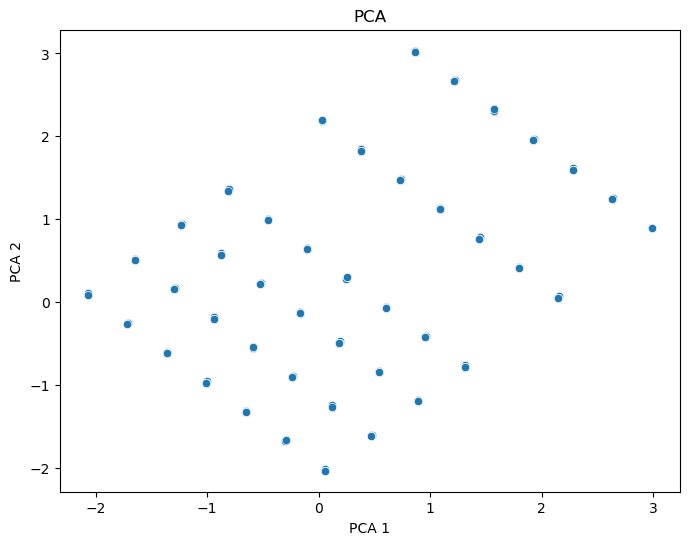

In [34]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='pca_1', y='pca_2')
plt.title("PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

---

### Parte 3: Aplicación de KMeans (30 min)
- Cómo funciona KMeans y su objetivo.
- Elección del número de clusters (`Elbow method`).
- Visualización de resultados.

**Actividad:**
1. Visualizar el método del codo.
2. Establecer los clusters.
3. Graficar los resultados.
4. Analizar las características de cada cluster.

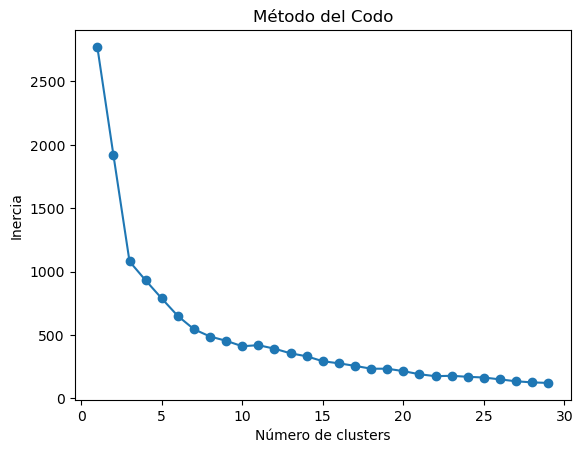

In [35]:

inertia = []
k_range = range(1, 30)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_cluster)
    inertia.append(model.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.show()

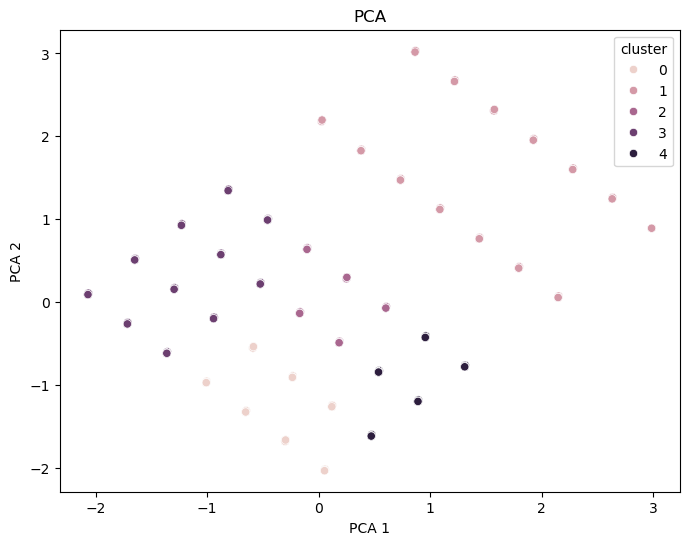

In [36]:
# Aplicamos KMeans con el número de clusters elegido
kmeans = KMeans(n_clusters=5, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_cluster)

# Reducción de dimensiones para visualizar
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='pca_1', y='pca_2', hue="cluster")
plt.title("PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

---

### Parte 4: Interpretación de Resultados y Conexión con KPIs (20 min)
- Identificación de perfiles de usuarios.
- Cómo se relacionan los clusters con el LTV (Lifetime Value) u otros KPIs.
- Implicaciones para estrategias de negocio (retención, marketing, precios).

**Discusión guiada:**
- ¿Cuál cluster es más rentable?
- ¿Cuáles deberían recibir incentivos?

#### Identificación de perfiles de usuarios

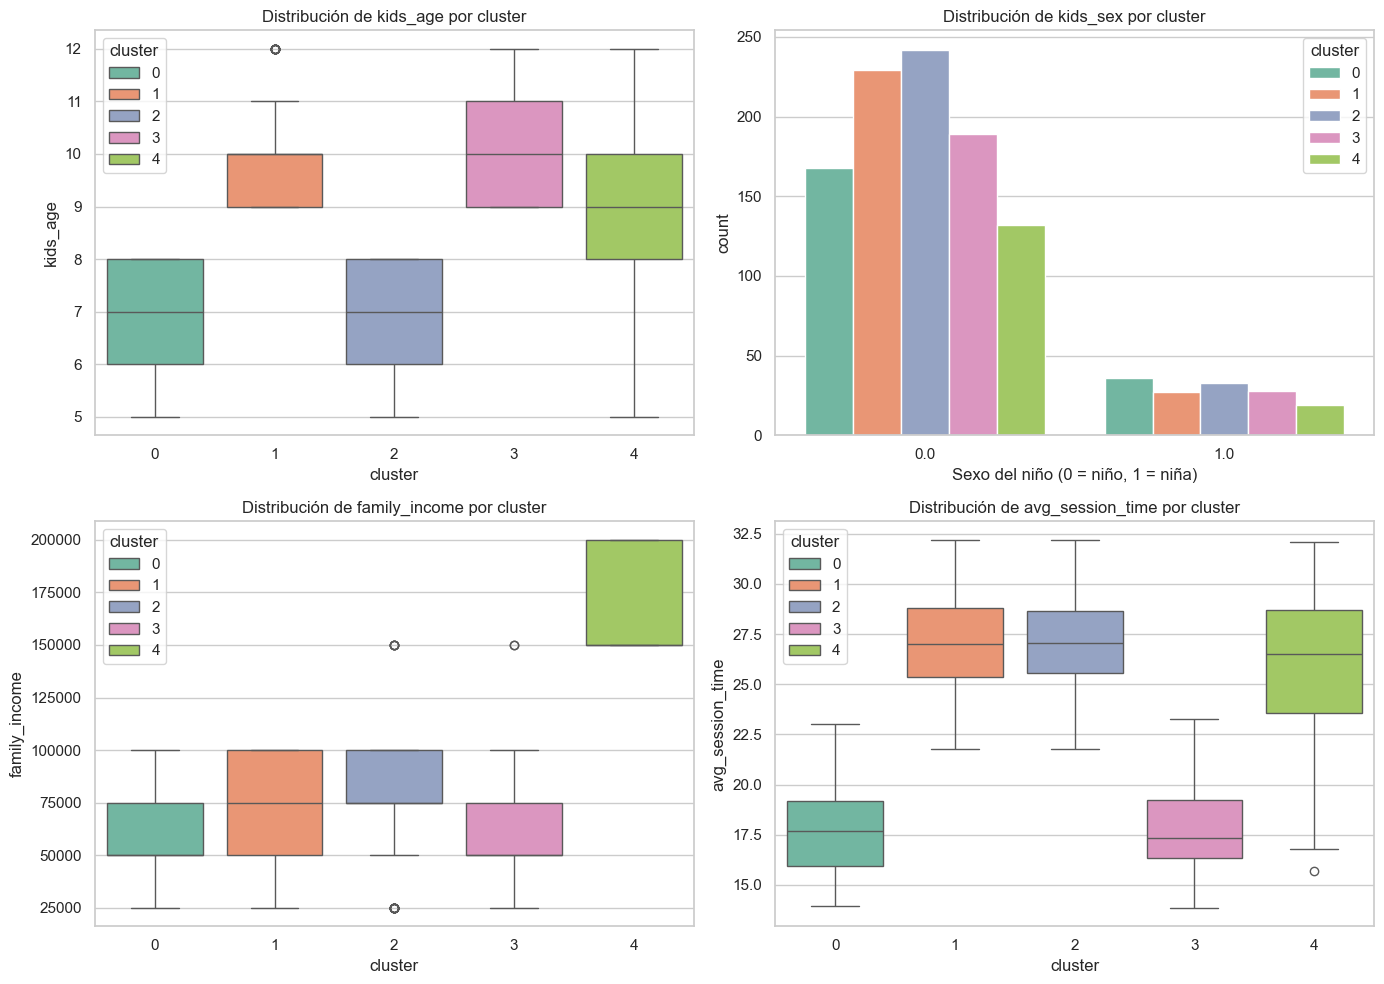

In [110]:
# Configuración general del layout
sns.set(style="whitegrid")
num_cols = 2
num_rows = int(np.ceil(len(features) / num_cols))

plt.figure(figsize=(14, 5 * num_rows))

for i, feature in enumerate(features, 1):
    plt.subplot(num_rows, num_cols, i)

    if feature not in numerical_features:
        # Gráfico de barras para variable categórica
        sns.countplot(data=df_clean, x=feature, hue='cluster', palette='Set2')
        plt.title(f'Distribución de {feature} por cluster')
        plt.xlabel("Sexo del niño (0 = niño, 1 = niña)")
    else:
        # Boxplot para variables numéricas
        sns.boxplot(data=df_clean, x='cluster', y=feature, hue='cluster', palette='Set2')
        plt.title(f'Distribución de {feature} por cluster')

plt.tight_layout()
plt.show()


In [95]:
# Agregamos KPIs por cluster
kpi_cols = ['monthly_fee', 'avg_session_time', 'customer_support_tickets', 'tenure', 'churn']
cluster_summary = df_clean.groupby('cluster')[kpi_cols].mean().round(2)
cluster_summary

,monthly_fee,avg_session_time,customer_support_tickets,tenure,churn
cluster,,,,,
0,15.00,26.85,2.21,10.08,0.37
1,15.32,41.63,2.17,17.15,0.29
2,17.05,31.86,2.13,12.31,0.33
3,14.65,41.82,2.13,17.52,0.28
4,15.30,25.83,2.17,9.14,0.34


---

### Cierre y Reflexión (10 min)
- Beneficios del clustering en contexto empresarial.
- Ventajas y limitaciones.
- Posibles extensiones (DBSCAN, GMM, clustering con embeddings).

---

### Recursos y Referencias
- [Scikit-learn Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [Guía PCA + Clustering](https://rich-d-wilkinson.github.io/MATH3030/part-ii-dimension-reduction-methods.html)
